# Polynomial Regression with Synthetic Data

## Project Overview

This project demonstrates polynomial regression using randomly generated nonlinear data. The goal is to show how polynomial features allow a linear regression model to capture curved relationships between variables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Generate random nonlinear data

In [2]:
np.random.seed(42)

X = np.random.uniform(-5,5, 100).reshape(-1,1)

# Error
noise = np.random.normal(0, 3, 100).reshape(-1, 1)

y = 3 + 2 * X - 0.8 * X**2 + noise

# Convert to a DataFrame for easier viewing
df = pd.DataFrame({
    "X": X.flatten(),
    "y": y.flatten()
})

df.head()

,X,y
0,-1.254599,-0.507271
1,4.507143,-5.134207
2,2.319939,3.609466
3,0.986585,-1.768217
4,-3.439814,-14.004497


### Visualize

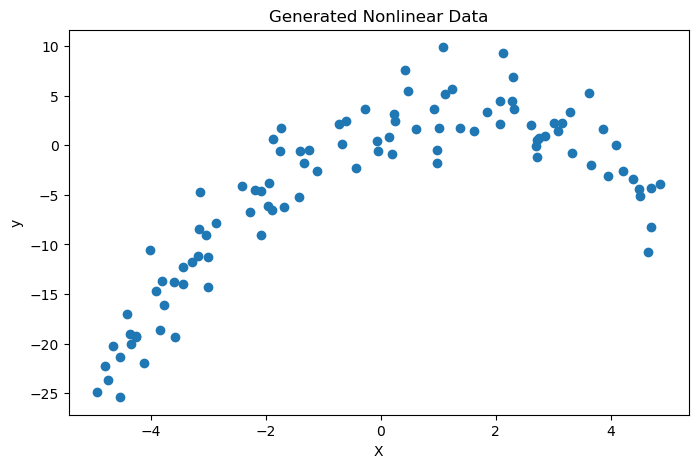

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(df["X"], df["y"])
plt.xlabel("X")
plt.ylabel("y")
plt.title("Generated Nonlinear Data")
plt.show()

### Split data

In [4]:
X = df[["X"]]
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (80, 1)
Test set size: (20, 1)


### Fit a simple linear regression model

In [5]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

### Evaluate the linear regression model

In [6]:
linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("-----------------------------")
print(f"MAE:  {linear_mae:.3f}")
print(f"RMSE: {linear_rmse:.3f}")
print(f"R2:   {linear_r2:.3f}")

Linear Regression Performance
-----------------------------
MAE:  4.734
RMSE: 5.637
R2:   0.574


### Fit a polynomial regression model

In [7]:
polynomial_model = Pipeline(
    steps=[
        ("poly_features", PolynomialFeatures(degree=2, include_bias=False)),
        ("linear_regression", LinearRegression())
    ]
)

polynomial_model.fit(X_train, y_train)

y_pred_poly = polynomial_model.predict(X_test)

### Evaluate the polynomial regression model

In [9]:
poly_mae = mean_absolute_error(y_test, y_pred_poly)
poly_rmse = np.sqrt(mean_squared_error(y_test, y_pred_poly))
poly_r2 = r2_score(y_test, y_pred_poly)

print("Polynomial Regression Performance")
print("---------------------------------")
print(f"MAE:  {poly_mae:.3f}")
print(f"RMSE: {poly_rmse:.3f}")
print(f"R2:   {poly_r2:.3f}")

Polynomial Regression Performance
---------------------------------
MAE:  1.734
RMSE: 2.392
R2:   0.923


In [ ]:
### Compare model performance

In [10]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Regression Degree 2"],
    "MAE": [linear_mae, poly_mae],
    "RMSE": [linear_rmse, poly_rmse],
    "R2": [linear_r2, poly_r2]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,4.734183,5.637429,0.573577
1,Polynomial Regression Degree 2,1.733995,2.392188,0.923216


### Visualize

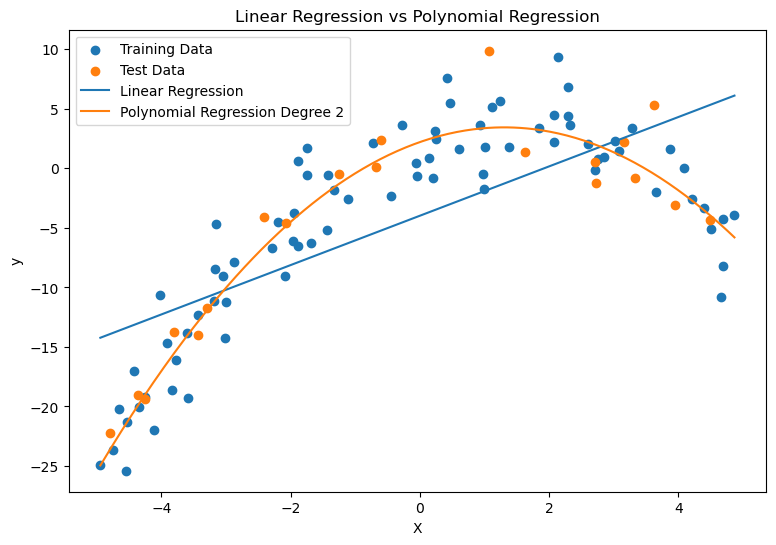

In [11]:
# Create smooth values for plotting model curves
X_range = np.linspace(X["X"].min(), X["X"].max(), 300).reshape(-1, 1)

# Convert to DataFrame to preserve feature names
X_range_df = pd.DataFrame(X_range, columns=["X"])

# Predictions
y_range_linear = linear_model.predict(X_range_df)
y_range_poly = polynomial_model.predict(X_range_df)

plt.figure(figsize=(9, 6))

plt.scatter(X_train, y_train, label="Training Data")
plt.scatter(X_test, y_test, label="Test Data")

plt.plot(X_range_df, y_range_linear, label="Linear Regression")
plt.plot(X_range_df, y_range_poly, label="Polynomial Regression Degree 2")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression vs Polynomial Regression")
plt.legend()
plt.show()

In [12]:
degree_results = []

for degree in range(1, 11):
    
    model = Pipeline(
        steps=[
            ("poly_features", PolynomialFeatures(degree=degree, include_bias=False)),
            ("linear_regression", LinearRegression())
        ]
    )
    
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    test_r2 = r2_score(y_test, test_pred)
    
    degree_results.append({
        "Degree": degree,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Test R2": test_r2
    })

degree_results_df = pd.DataFrame(degree_results)

degree_results_df

,Degree,Train RMSE,Test RMSE,Test R2
0,1,6.088937,5.637429,0.573577
1,2,2.707848,2.392188,0.923216
2,3,2.695834,2.403839,0.922466
3,4,2.662171,2.490411,0.916781
4,5,2.659494,2.484639,0.917167
5,6,2.653554,2.515244,0.915113
6,7,2.652724,2.527560,0.914280
7,8,2.652646,2.529041,0.914180
8,9,2.647001,2.493321,0.916587
9,10,2.633147,2.439433,0.920153


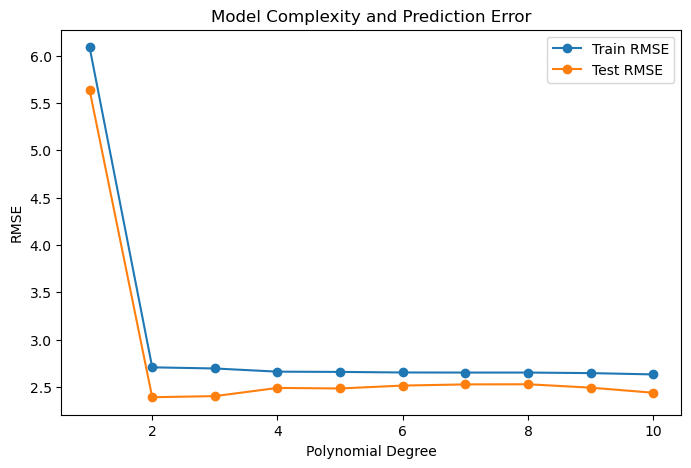

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    degree_results_df["Degree"],
    degree_results_df["Train RMSE"],
    marker="o",
    label="Train RMSE"
)

plt.plot(
    degree_results_df["Degree"],
    degree_results_df["Test RMSE"],
    marker="o",
    label="Test RMSE"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("RMSE")
plt.title("Model Complexity and Prediction Error")
plt.legend()
plt.show()

### Best Model

In [14]:
best_model_row = degree_results_df.loc[degree_results_df["Test RMSE"].idxmin()]

best_degree = int(best_model_row["Degree"])

print("Best Polynomial Degree")
print("----------------------")
print(f"Degree: {best_degree}")
print(f"Test RMSE: {best_model_row['Test RMSE']:.3f}")
print(f"Test R2: {best_model_row['Test R2']:.3f}")

Best Polynomial Degree
----------------------
Degree: 2
Test RMSE: 2.392
Test R2: 0.923


A very low degree may underfit the data.

A very high degree may overfit the training data.

The best model is usually the one with the lowest test RMSE. In this case, a polynomial with degree=2 is best.

### Train the final polynomial regression model

In [15]:
final_model = Pipeline(
    steps=[
        ("poly_features", PolynomialFeatures(degree=best_degree, include_bias=False)),
        ("linear_regression", LinearRegression())
    ]
)

final_model.fit(X_train, y_train)

final_predictions = final_model.predict(X_test)

final_mae = mean_absolute_error(y_test, final_predictions)
final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
final_r2 = r2_score(y_test, final_predictions)

print("Final Polynomial Regression Model")
print("---------------------------------")
print(f"Best Degree: {best_degree}")
print(f"MAE:         {final_mae:.3f}")
print(f"RMSE:        {final_rmse:.3f}")
print(f"R2:          {final_r2:.3f}")

Final Polynomial Regression Model
---------------------------------
Best Degree: 2
MAE:         1.734
RMSE:        2.392
R2:          0.923


### Make a single prediction

In [16]:
new_data = pd.DataFrame({
    "X": [2.5]
})

single_prediction = final_model.predict(new_data)

print(f"Predicted y value: {single_prediction[0]:.3f}")

Predicted y value: 2.406


### Extract model coefficients

In [18]:
# Get polynomial feature names
feature_names = final_model.named_steps["poly_features"].get_feature_names_out(["X"])

# Get coefficients
coefficients = final_model.named_steps["linear_regression"].coef_

# Get intercept
intercept = final_model.named_steps["linear_regression"].intercept_

coef_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

print("Intercept:", intercept)
coef_table

Intercept: 2.2087745758356014


,Feature,Coefficient
0,X,1.897131
1,X^2,-0.727357


## Key Findings

The simple linear regression model underfits the data because the relationship between `X` and `y` is nonlinear. Polynomial regression improves predictive performance by adding higher-order terms such as `X²`. However, very high polynomial degrees can overfit the training data, leading to worse test performance.